In [105]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
train_path = '../../../data/raw/train.csv'
test_path = '../../../data/raw/test.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [107]:
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) & (train_data['SalePrice'] < 300000)].index)
train_data=train_data.drop(train_data[(train_data["LotArea"] >100000)].index)
train_data=train_data.drop(train_data[(train_data['LotFrontage']>300)].index)

In [108]:
columns_None = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','GarageType','GarageFinish','GarageQual','FireplaceQu','GarageCond']
train_data[columns_None]= train_data[columns_None].fillna('None')
test_data[columns_None]= test_data[columns_None].fillna('None')

In [109]:
columns_with_lownullvalues = ['MSZoning','Utilities','Exterior1st','Exterior2nd','Electrical','KitchenQual','Functional','SaleType']

test_data[columns_with_lownullvalues] = test_data[columns_with_lownullvalues].fillna(test_data.mode().iloc[0])
train_data[columns_with_lownullvalues] = train_data[columns_with_lownullvalues].fillna(train_data.mode().iloc[0])

In [110]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(train_data['YrSold']-35)
test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(test_data['YrSold']-35)
train_data['LotFrontage'] = train_data['LotFrontage'].fillna(68)
test_data['LotFrontage'] = test_data['LotFrontage'].fillna(68)

In [111]:
train_data = train_data.drop(['Heating','RoofMatl','Condition2','Street','Utilities'],axis=1)
test_data = test_data.drop(['Heating','RoofMatl','Condition2','Street','Utilities'],axis=1)

In [112]:
train_data["SalePrice"] = np.log1p(train_data["SalePrice"])
train_data["TotalSF"] = train_data["TotalBsmtSF"] + train_data["1stFlrSF"] + train_data["2ndFlrSF"]
test_data["TotalSF"] = test_data["TotalBsmtSF"] + test_data["1stFlrSF"] + test_data["2ndFlrSF"]

train_data["HouseAge"] = train_data["YrSold"] - train_data["YearBuilt"]
test_data["HouseAge"] = test_data["YrSold"] - test_data["YearBuilt"]

negative_age_mask = test_data['HouseAge'] < 0

test_data.loc[negative_age_mask, ['YrSold', 'YearRemodAdd']] = 2008
test_data.loc[negative_age_mask, 'HouseAge'] = 0

train_data['HouseAge'] = train_data['HouseAge'] + 1
test_data['HouseAge'] = test_data['HouseAge'] + 1

train_data['YearsSinceRemodel'] = train_data['YrSold'] - train_data['YearRemodAdd']
test_data['YearsSinceRemodel'] = test_data['YrSold'] - test_data['YearRemodAdd']

# First identify the rows with negative HomeAgeAtSale
negative_age_maskk = test_data['YearsSinceRemodel'] < 0
test_data.loc[negative_age_maskk, ['YearRemodAdd']] = 2007
test_data.loc[negative_age_maskk, 'YearsSinceRemodel'] = 0

negative_age_maskkk = train_data['YearsSinceRemodel'] < 0
train_data.loc[negative_age_maskkk, ['YearRemodAdd']] = 2007
train_data.loc[negative_age_maskkk, 'YearsSinceRemodel'] = 0

train_data['YearsSinceRemodel'] = train_data['YearsSinceRemodel'] + 1
test_data['YearsSinceRemodel'] = test_data['YearsSinceRemodel'] + 1

train_data["QualCond"] = train_data["OverallQual"]*train_data["OverallCond"]
test_data["QualCond"] = test_data["OverallQual"]*test_data["OverallCond"]

train_data['TotalBsmtBath'] = train_data['BsmtFullBath'] + train_data['BsmtFullBath']*0.5
train_data['TotalBath'] = train_data['FullBath'] + train_data['HalfBath']*0.5 

test_data['TotalBsmtBath'] = test_data['BsmtFullBath'] + test_data['BsmtFullBath']*0.5
test_data['TotalBath'] = test_data['FullBath'] + test_data['HalfBath']*0.5 



In [113]:
train_data['HasBasement'] = (
    train_data['BsmtQual'] != 'None'
).map({True: 1, False: 0})

test_data['HasBasement'] = (
    train_data['BsmtQual'] != 'None'
).map({True: 1, False: 0})

train_data['IsHomeNew'] = (
    train_data['SaleType'] == 'New'
).map({True: 1, False: 0})

test_data['IsHomeNew'] = (
    test_data['SaleType'] == 'New'
).map({True: 1, False: 0})

train_data['HasGarage'] = train_data['GarageFinish'] != 'None'
train_data['HasGarage'] = train_data['HasGarage'].map({True: 1, False: 0})

test_data['HasGarage'] = test_data['GarageFinish'] != 'None'
test_data['HasGarage'] = test_data['HasGarage'].map({True: 1, False: 0})

train_data['HasSecondGarage'] = train_data['MiscFeature'] == 'Gar2'
train_data['HasSecondGarage'] = train_data['HasSecondGarage'].map({True: 1, False: 0})

test_data['HasSecondGarage'] = test_data['MiscFeature'] == 'Gar2'
test_data['HasSecondGarage'] = test_data['HasSecondGarage'].map({True: 1, False: 0})

train_data['MultipleExteriorMaterials'] = (
    (train_data['Exterior1st'] != train_data['Exterior2nd']).astype(int)
)

test_data['MultipleExteriorMaterials'] = (
    (test_data['Exterior1st'] != test_data['Exterior2nd']).astype(int)
)

test_data['HasMasonryVeneer'] = (test_data['MasVnrType'] != 'None').astype(int)

train_data['HasMasonryVeneer'] = (train_data['MasVnrType'] != 'None').astype(int)

In [114]:
train_data=train_data.drop(['PoolQC','MiscFeature','Alley','Fence','MasVnrType'],axis=1)
test_data=test_data.drop(['PoolQC','MiscFeature','Alley','Fence','MasVnrType'],axis=1)

In [115]:
target = "SalePrice"
numerical_features = train_data.select_dtypes(include=['float64', 'int64']).columns
categorical_features = train_data.select_dtypes(include='object').columns
num_features = [col for col in numerical_features if col != target]

# Fill missing
train_data[categorical_features] = train_data[categorical_features].fillna("Missing")
test_data[categorical_features] = test_data[categorical_features].fillna("Missing")
train_data[num_features] = train_data[num_features].fillna(0)
test_data[num_features] = test_data[num_features].fillna(0)

# Đồng nhất categories giữa train và test
for col in categorical_features:
    all_values = pd.concat([train_data[col], test_data[col]], axis=0).astype(str).unique()
    train_data[col] = pd.Categorical(train_data[col].astype(str), categories=all_values)
    test_data[col] = pd.Categorical(test_data[col].astype(str), categories=all_values)

In [116]:
ordinal_maps = {
    'ExterQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'HeatingQC': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
    'LandContour': {'Lvl': 3, 'Bnk': 2, 'HLS': 1, 'Low': 0},
    'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
}
for col, mapping in ordinal_maps.items():
    train_data[col] = train_data[col].map(mapping)
    test_data[col] = test_data[col].map(mapping)

# 2. One-hot cho các cột phân loại không có thứ bậc
categorical_cols = [col for col in train_data.select_dtypes(include=['object']).columns if col not in ordinal_maps]

train_data = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)
test_data = pd.get_dummies(test_data, columns=categorical_cols, drop_first=True)

# 3. Đồng bộ cột giữa train và test
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

In [117]:
train = train_data.copy()
test = test_data.copy()

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: LightGBM_regression_best_211506
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0188669:   5%|▌         | 1/20 [00:00<00:13,  1.39it/s]

[I 2025-10-28 21:15:06,795] Trial 0 finished with value: -0.018866918073006833 and parameters: {'n_estimators': 905, 'learning_rate': 0.07321080628095127, 'max_depth': 5, 'num_leaves': 165, 'subsample': 0.5261357303864842, 'colsample_bytree': 0.9180910609673927, 'lambda_l1': 0.44947124553587325, 'lambda_l2': 0.7330932134097704, 'min_child_samples': 61}. Best is trial 0 with value: -0.018866918073006833.


Best trial: 0. Best value: -0.0188669:  10%|█         | 2/20 [00:01<00:08,  2.01it/s]

...

[I 2025-10-28 21:15:27,947] Trial 17 finished with value: -0.016792920105131143 and parameters: {'n_estimators': 1515, 'learning_rate': 0.020017407278894457, 'max_depth': 4, 'num_leaves': 136, 'subsample': 0.7320431162401383, 'colsample_bytree': 0.8544835053376445, 'lambda_l1': 4.473627297400541e-05, 'lambda_l2': 2.1316089530175964e-05, 'min_child_samples': 31}. Best is trial 12 with value: -0.015442565338448686.


Best trial: 12. Best value: -0.0154426:  95%|█████████▌| 19/20 [00:22<00:01,  1.21s/it]

[I 2025-10-28 21:15:28,760] Trial 18 finished with value: -0.019287433861471404 and parameters: {'n_estimators': 1017, 'learning_rate': 0.012112232669501915, 'max_depth': 4, 'num_leaves': 87, 'subsample': 0.6382204299809362, 'colsample_bytree': 0.626730646009226, 'lambda_l1': 0.004049901188781803, 'lambda_l2': 0.009574643890423316, 'min_child_samples': 80}. Best is trial 12 with value: -0.015442565338448686.


Best trial: 12. Best value: -0.0154426: 100%|██████████| 20/20 [00:24<00:00,  1.22s/it]


[I 2025-10-28 21:15:30,551] Trial 19 finished with value: -0.019984890381765225 and parameters: {'n_estimators': 1438, 'learning_rate': 0.10716860034974822, 'max_depth': 7, 'num_leaves': 124, 'subsample': 0.9910580324014947, 'colsample_bytree': 0.7145219805649811, 'lambda_l1': 1.2625696015771383e-07, 'lambda_l2': 9.078878646647305e-06, 'min_child_samples': 55}. Best is trial 12 with value: -0.015442565338448686.
✅ Best params (Optuna): {'n_estimators': 1617, 'learning_rate': 0.010766767918048484, 'max_depth': 3, 'num_leaves': 105, 'subsample': 0.6821772712649913, 'colsample_bytree': 0.715513895618578, 'lambda_l1': 1.2423310442518989e-08, 'lambda_l2': 0.0008697961748748107, 'min_child_samples': 20}
🎯 Best params sau tuning: {'n_estimators': 1617, 'learning_rate': 0.010766767918048484, 'max_depth': 3, 'num_leaves': 105, 'subsample': 0.6821772712649913, 'colsample_bytree': 0.715513895618578, 'lambda_l1': 1.2423310442518989e-08, 'lambda_l2': 0.0008697961748748107, 'min_child_samples': 20}


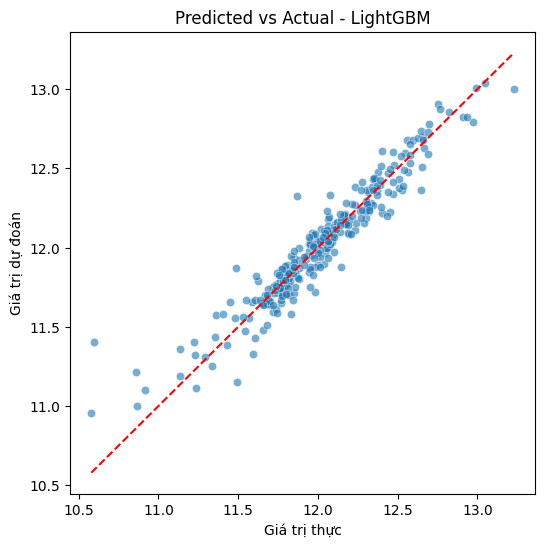

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


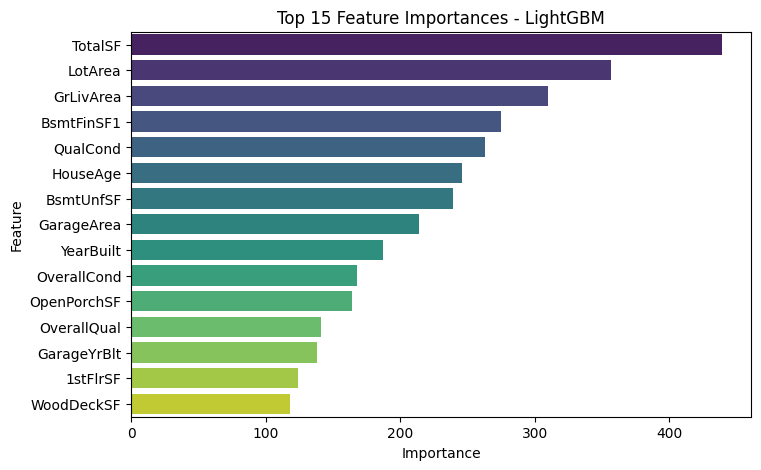

2025/10/28 21:15:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Đã chạy đánh giá đầy đủ cho task: regression.
✅ Mô hình đã lưu local: experiments/models\LightGBM_regression_best_211506_20251028_211531_model.pkl


2025/10/28 21:15:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_regression_best_211506_20251028_211534_data.csv


In [118]:
from pipeline.LightGBMPipline import LightGBMPipeline

pipeline = LightGBMPipeline(experiment_name="version4")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="LightGBM",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: XGBoost_regression_best_211534
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.0145374:   5%|▌         | 1/20 [00:00<00:13,  1.42it/s]

[I 2025-10-28 21:15:35,579] Trial 0 finished with value: -0.014537360402180177 and parameters: {'n_estimators': 1996, 'learning_rate': 0.10990250892591412, 'max_depth': 3, 'subsample': 0.6746979377698734, 'colsample_bytree': 0.5580671986343008, 'reg_alpha': 1.660451881723773e-05, 'reg_lambda': 1.0009294633402086e-08, 'min_child_weight': 2, 'gamma': 0.02717195302023468}. Best is trial 0 with value: -0.014537360402180177.


Best trial: 0. Best value: -0.0145374:  10%|█         | 2/20 [00:03<00:34,  1.90s/it]

...

Best trial: 0. Best value: -0.0145374:  95%|█████████▌| 19/20 [00:27<00:01,  1.24s/it]

[I 2025-10-28 21:16:02,071] Trial 18 finished with value: -0.01509838404531881 and parameters: {'n_estimators': 1831, 'learning_rate': 0.06508307229713964, 'max_depth': 5, 'subsample': 0.6884164772491087, 'colsample_bytree': 0.5596261966122879, 'reg_alpha': 0.00028138960665056875, 'reg_lambda': 2.3529626233644894e-07, 'min_child_weight': 5, 'gamma': 0.0120459049211223}. Best is trial 0 with value: -0.014537360402180177.


Best trial: 0. Best value: -0.0145374: 100%|██████████| 20/20 [00:30<00:00,  1.53s/it]

[I 2025-10-28 21:16:05,491] Trial 19 finished with value: -0.01529090913404247 and parameters: {'n_estimators': 1981, 'learning_rate': 0.056660419594271774, 'max_depth': 11, 'subsample': 0.5858522279830649, 'colsample_bytree': 0.6594041764320862, 'reg_alpha': 3.64421212190545e-08, 'reg_lambda': 9.992267264624841, 'min_child_weight': 7, 'gamma': 6.832376453755882e-06}. Best is trial 0 with value: -0.014537360402180177.
✅ Best params (Optuna): {'n_estimators': 1996, 'learning_rate': 0.10990250892591412, 'max_depth': 3, 'subsample': 0.6746979377698734, 'colsample_bytree': 0.5580671986343008, 'reg_alpha': 1.660451881723773e-05, 'reg_lambda': 1.0009294633402086e-08, 'min_child_weight': 2, 'gamma': 0.02717195302023468, 'enable_categorical': True, 'random_state': 42}
🚀 Huấn luyện mô hình XGBoost với 1162 mẫu...
[0]	validation_0-rmse:0.35642


[200]	validation_0-rmse:0.11899
[400]	validation_0-rmse:0.11838
[600]	validation_0-rmse:0.11798
[800]	validation_0-rmse:0.11843
[1000]	validation_0-rmse:0.11800
[1200]	validation_0-rmse:0.11800
[1400]	validation_0-rmse:0.11829
[1600]	validation_0-rmse:0.11832
[1800]	validation_0-rmse:0.11832
[1995]	validation_0-rmse:0.11830

🔹 Evaluation Report for XGBoost (regression)

 Tổng hợp metrics:
        XGBoost
MAE    0.078740
RMSE   0.118302
RMSLE  0.009301
R²     0.907246


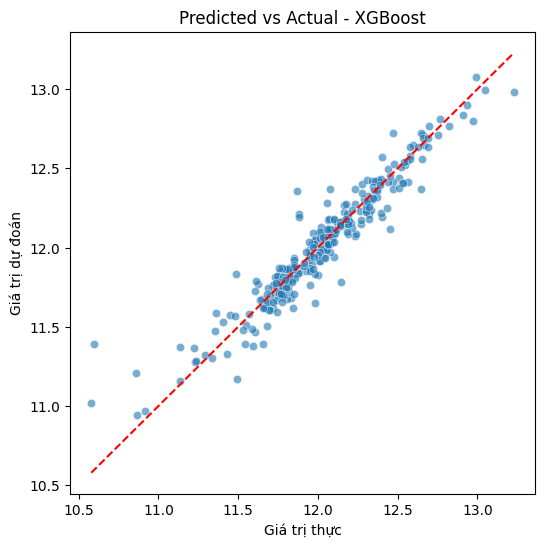

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


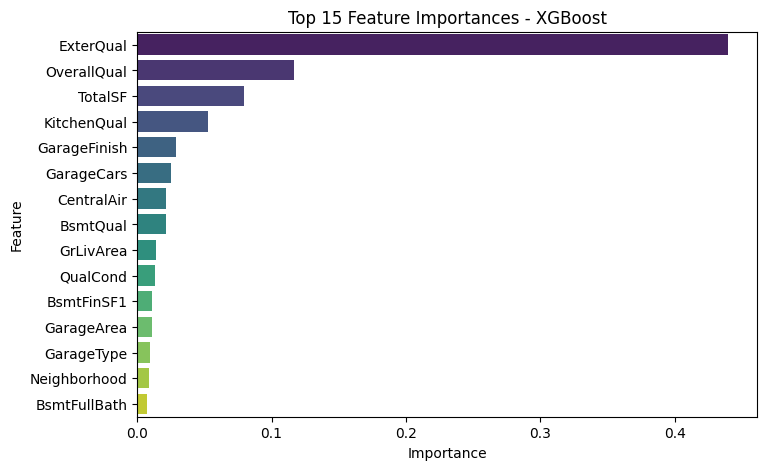

2025/10/28 21:16:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_regression_best_211534_20251028_211609_model.pkl


2025/10/28 21:16:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_regression_best_211534_20251028_211612_data.csv


In [119]:
from pipeline.XGBoostPipeline import XGBoostPipeline
pipeline = XGBoostPipeline(experiment_name="version4")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="XGBoost",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: CatBoost_regression_best_211612
🔍 Phát hiện 33 cột phân loại: ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]


[W 2025-10-28 21:16:12,285] Trial 0 failed with parameters: {'depth': 7, 'learning_rate': 0.09920356528066109, 'iterations': 705, 'l2_leaf_reg': 0.08467935941755889, 'subsample': 0.6004272006051206, 'colsample_bylevel': 0.6297259175666374} because of the following error: TypeError("catboost.core.CatBoostRegressor() got multiple values for keyword argument 'random_seed'").
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\model\Catboost.py", line 65, in _objective

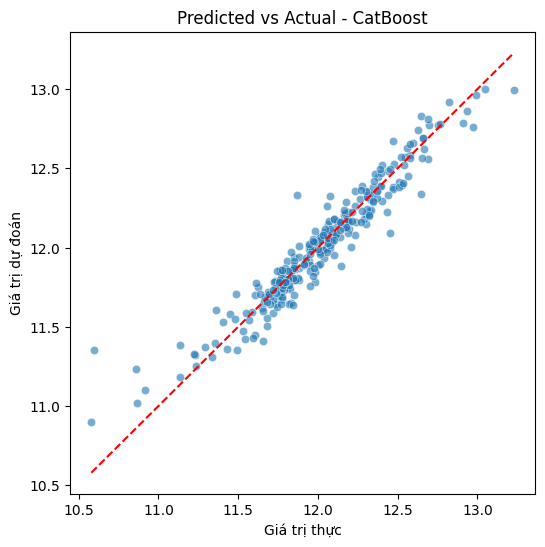

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


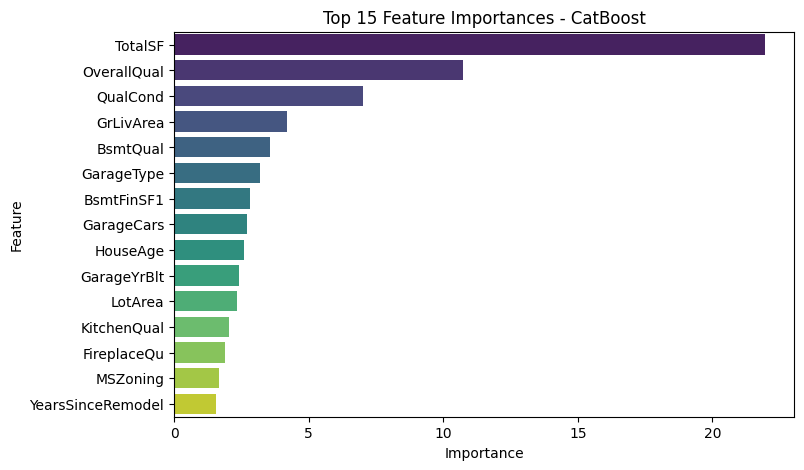

2025/10/28 21:16:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_regression_best_211612_20251028_211638_model.pkl


2025/10/28 21:16:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_regression_best_211612_20251028_211641_data.csv


In [120]:
from pipeline.CatBoostPipeline import CatBoostPipeline
pipeline = CatBoostPipeline(experiment_name="version4")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="CatBoost",
    backend="mlflow"
)

Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: RandomForest_regression_best_211641
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


Best trial: 0. Best value: -0.020222:   5%|▌         | 1/20 [00:00<00:04,  3.94it/s]

[I 2025-10-28 21:16:42,153] Trial 0 finished with value: -0.020221983148692137 and parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_samples': 0.8345203626970086}. Best is trial 0 with value: -0.020221983148692137.


Best trial: 0. Best value: -0.020222:  10%|█         | 2/20 [00:00<00:05,  3.43it/s]

...

[I 2025-10-28 21:16:56,451] Trial 17 finished with value: -0.019484879417367786 and parameters: {'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_samples': 0.7673491882951918}. Best is trial 5 with value: -0.01896490068561764.


Best trial: 18. Best value: -0.0188063:  95%|█████████▌| 19/20 [00:15<00:01,  1.24s/it]

[I 2025-10-28 21:16:57,726] Trial 18 finished with value: -0.018806338082707066 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.7168238474043378}. Best is trial 18 with value: -0.018806338082707066.


Best trial: 18. Best value: -0.0188063: 100%|██████████| 20/20 [00:16<00:00,  1.18it/s]


[I 2025-10-28 21:16:58,859] Trial 19 finished with value: -0.018972193173044348 and parameters: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.7326850589191886}. Best is trial 18 with value: -0.018806338082707066.
✅ Best params (Optuna): {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.7168238474043378, 'random_state': 42, 'n_jobs': -1}
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest (regression)

 Tổng hợp metrics:
       RandomForest
MAE        0.083906
RMSE       0.124437
RMSLE      0.009813
R²         0.897377


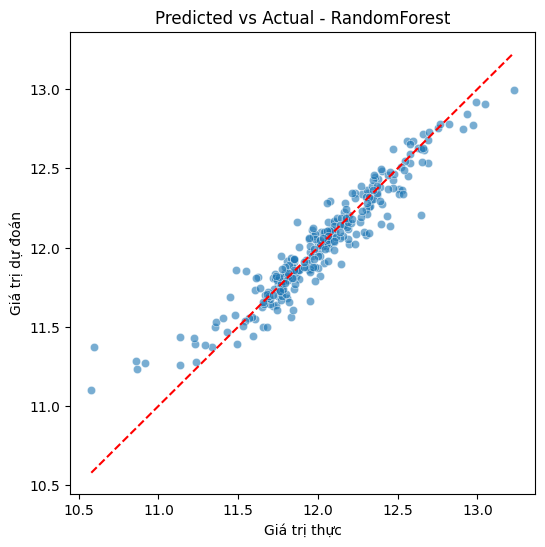

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


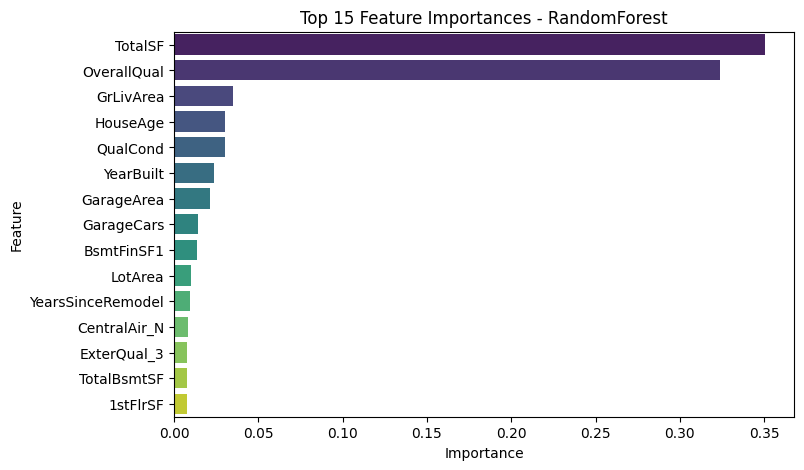

2025/10/28 21:16:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Model đã được lưu tại: experiments/models\RandomForest_best.pkl
✅ Mô hình đã lưu local: experiments/models\RandomForest_regression_best_211641_20251028_211659_model.pkl


2025/10/28 21:17:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_regression_best_211641_20251028_211702_data.csv


In [121]:
from pipeline.RFPipline import RFPipeline
pipeline = RFPipeline(experiment_name="version4")
pipeline.run(
    df=train,
    target_col=target,
    task="regression",
    model_name="RandomForest",
    backend="mlflow"
)

In [122]:
import joblib
model_da_load = joblib.load('experiments/models/CatBoost_regression_best_211054_20251028_211121_model.pkl')
Xgb_preds = model_da_load.predict(test)
y_log_preds = np.expm1(Xgb_preds)
submission= pd.DataFrame({'Id': test.Id,'SalePrice':y_log_preds })
submission.to_csv('submission.csv',index=False)